In [ ]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
import matplotlib as mpl

figsize(17, 3.2)
mpl.rcParams['agg.path.chunksize'] = 10000

In [ ]:
import numpy as np
import scipy.special as sp
from  scipy.constants import c
import matplotlib.pyplot as plt
#!pip install OptiCommPy
from optic.utils import parameters
from optic.dsp.core import firFilter, signal_power, pulseShape, upsample, pnorm
from optic.models.devices import mzm, photodiode
from optic.plot import eyediagram

## Dispersao e Perda.
---

## Sumário
---
- [Pulsos](#pulsos)
- [Equação de Propagação e Dispersão Cromática](#equação_de_propagação_e_dispersão_cromática)
- [Pulso Gaussiano "chirpado"](#pulso_gaussiano_"chirpado")
- [Transmissão 10G OOK apenas com dispersão e perdas](#transmissão_10G_OOK_apenas_com_dispersão_e_perdas)

### Pulsos
---

#### Pulso Gausiano

Pulso ideal em teoria e prática, O pulso Gaussiano é amplamente utilizado por apresentar propriedades ideais: Simetria temporal e espectral, Transformada de Fourier também Gaussiana, Menor produto tempo-largura. O código abixo serve para estudar como a largura temporal $T_0$ de um pulso Gaussiano afeta sua largura espectral, conforme o teorema da dualidade tempo-frequência. Ele também mostra o excelente ajuste entre o modelo analítico e a implementação numérica via FFT. O Pulso Gaussiano pode ser expresso por:

$$
A(0,t) = A_0e^{-\frac{1}{2}(\frac{t}{T_o})^2}
$$



In [ ]:
def GaussPulse(a0, t0, t):
  return a0*np.exp(-0.5*(t/t0)**2)

T0 = np.array([0.2, 0.07])                   # Parâmetro meia largura
A0 = 1                                      # Amplitude do pulso
fs = 100                                    # Taxa de amostragem
NFFT = 1024                                 # Número de pontos da FFT
t  = np.arange(-0.5,0.5,1/fs)
f = fs/NFFT * np.arange(-NFFT/2,NFFT/2)
L = len(t)

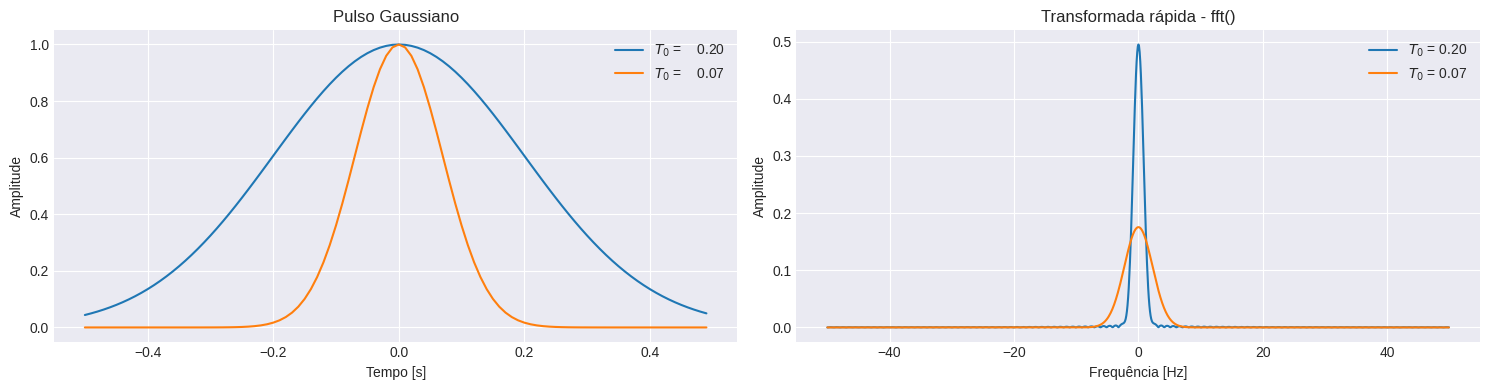

In [ ]:
plt.style.use("seaborn-v0_8-darkgrid")
fig, axs = plt.subplots(1, 2, figsize=(15,4))
for i in range(len(T0)):
  x   = GaussPulse(A0, T0[i], t)
  axs[0].plot(t, x, label = r"$T_0$ = %7.2f" % (T0[i]))
  axs[0].set_xlabel("Tempo [s]")
  axs[0].set_ylabel("Amplitude")
  axs[0].legend()
  axs[0].set_title("Pulso Gaussiano")

  Xf  = np.fft.fftshift(np.fft.fft(x, NFFT))
  axs[1].plot(f, abs(Xf)/L, label = r"$T_0$ = %3.2f" % (T0[i]))
  axs[1].set_xlabel("Frequência [Hz]")
  axs[1].set_ylabel("Amplitude")
  axs[1].legend()
  axs[1].set_title("Transformada rápida - fft()")

plt.tight_layout()

#### Pulso super Gaussiano

O pulso Super Gaussiano é uma generalização da Gaussiana clássica. Sua expressão é, em que $m$ corresponde ao coeficiente de formato de borda. Para $m = 1$, é obtido o pulso Gaussiano descrito anteriormente. Para elevados valores de $m$ o pulso apresenta formato próximo ao retangular. O Pulso Super Gaussiano pode ser expresso por:

$$
A(0,t) = A_0e^{-\frac{1}{2}(\frac{t}{T_o})^{2m}}
$$

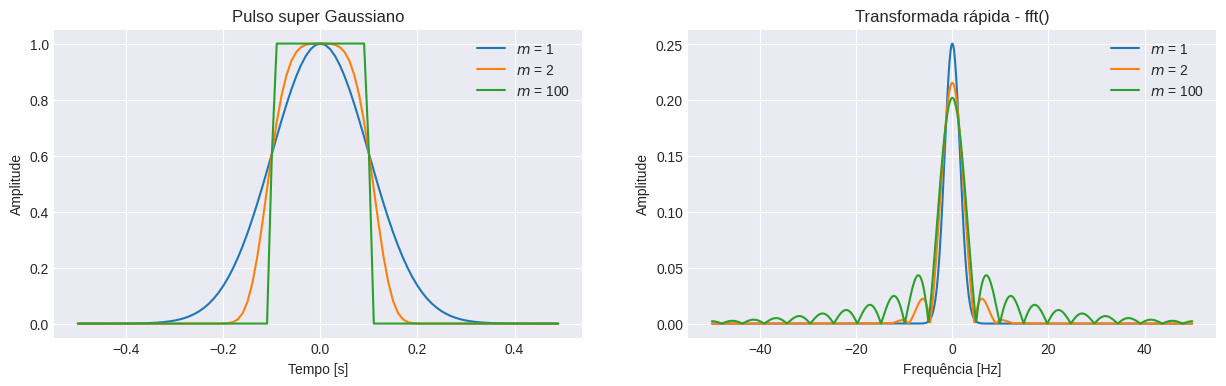

In [ ]:
def SuperGaussPulse(a0, t0, t, m):
  return a0*np.exp(-0.5*(t/t0)**(2*m))

T0 = 0.1
m  = np.array([1, 2, 100])

fig, axs = plt.subplots(1,2, figsize=(15,4))
for i in range(len(m)):
  x   = SuperGaussPulse(A0, T0, t, m[i])
  axs[0].plot(t, x, label = r"$m$ = %d" % (m[i]))
  axs[0].set_xlabel("Tempo [s]")
  axs[0].set_ylabel("Amplitude")
  axs[0].set_title("Pulso super Gaussiano")
  axs[0].legend()
  Xf  = np.fft.fftshift(np.fft.fft(x, NFFT))
  axs[1].plot(f, abs(Xf)/L, label = r"$m$ = %d" % (m[i]))
  axs[1].set_xlabel("Frequência [Hz]")
  axs[1].set_ylabel("Amplitude")
  axs[1].set_title("Transformada rápida - fft()")
  axs[1].legend()

#### Equação de Propagação e Dispersão Cromática
---

Quando um pulso de luz é lançado em uma fibra óptica, ele pode sofrer alargamento temporal devido à dispersão cromática(ou GVD — Group Velocity Dispersion). Isso acontece porque diferentes componentes espectrais (frequências) do pulso se propagam a velocidades ligeiramente diferentes.

No domínio da frequência, a solução da equação de propagação linear com GVD é dada por:

$$H(f) = H_0e^{j\frac{β_2}{2}zω^2},\ β_2 \text{ é o coeficiente de dispersão}$$

In [ ]:
def FGaussPulse(a0, t0, freq):  # Transformada de Fourier do pulso Gaussiano (analítica)
  return a0*t0*np.sqrt(2*np.pi)*np.exp(-0.5*(2*np.pi*freq*t0)**2)

fs = 256                        # Taxa de amostragem
NFFT = 256
t  = np.arange(-0.5,0.5,1/fs)
L = len(t)
f = fs/NFFT * np.arange(-NFFT/2,NFFT/2)
beta2 = 20e-6                   # parâmetro GVD
z = 250                         # distância de propagação
T0 = 0.05                       # Parâmetro meia largura
A0 = 1                          # Amplitude do pulso

#Função de dispersão do sinal
H  = np.exp(1j*0.5*beta2*z*(2*np.pi*f)**2)

x  = GaussPulse(A0, T0, t)
X  = FGaussPulse(A0, T0, f)
XH = X*H
xh  = np.fft.ifftshift(np.fft.ifft(XH))
xhA = T0/np.sqrt(T0**2-1j*beta2*z) * np.exp(-(t**2)/(2*(T0**2-1j*beta2*z)))

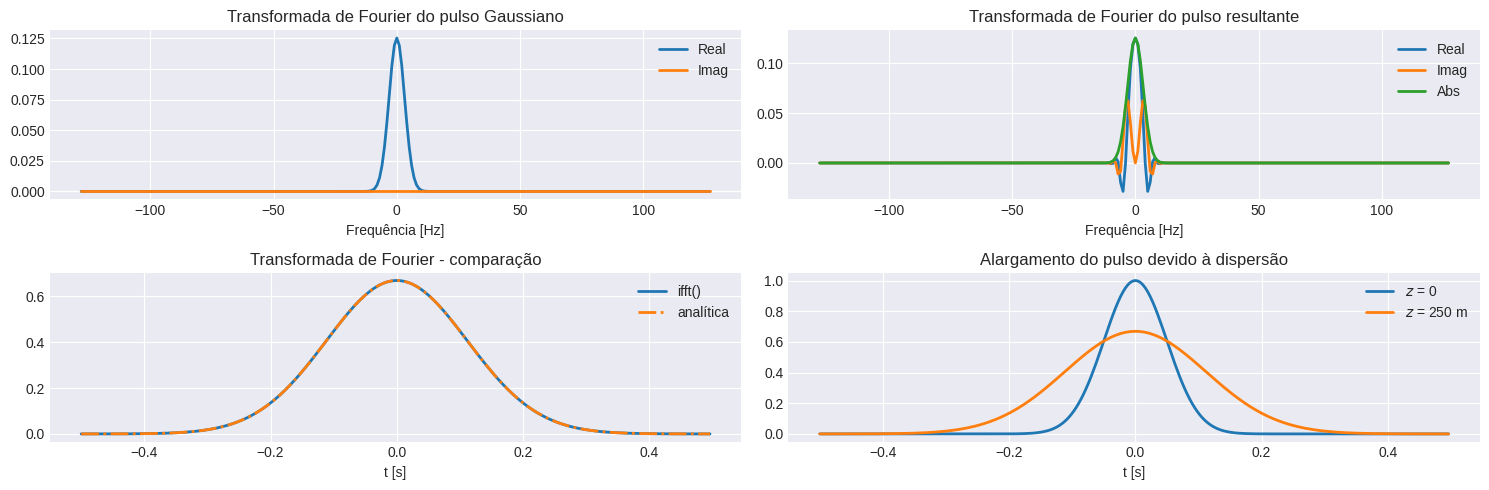

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(15,5))
axs[0,0].plot(f, X.real, label = "Real", linewidth = 2)
axs[0,0].plot(f, X.imag, label = "Imag", linewidth = 2)
axs[0,0].set_xlabel("Frequência [Hz]")
axs[0,0].set_title("Transformada de Fourier do pulso Gaussiano")
axs[0,0].legend()

axs[0,1].plot(f, XH.real, label = "Real", linewidth = 2)
axs[0,1].plot(f, XH.imag, label = "Imag", linewidth = 2)
axs[0,1].plot(f, np.abs(XH), label = "Abs", linewidth = 2)
axs[0,1].set_xlabel("Frequência [Hz]")
axs[0,1].set_title("Transformada de Fourier do pulso resultante")
axs[0,1].legend()

axs[1,0].plot(t, np.abs(xh*L), label = "ifft()", linewidth = 2)
axs[1,0].plot(t, np.abs(xhA), "-.", label = "analítica", linewidth = 2)
axs[1,0].set_xlabel("t [s]")
axs[1,0].set_title("Transformada de Fourier - comparação")
axs[1,0].legend()

axs[1,1].plot(t, x, label = r"$z$ = 0", linewidth = 2)
axs[1,1].plot(t, np.abs(xhA), label = r"$z$ = %d m" %(z), linewidth = 2)
axs[1,1].set_xlabel("t [s]")
axs[1,1].set_title("Alargamento do pulso devido à dispersão")
axs[1,1].legend()

plt.tight_layout()


Quando a frequência instantânea de um pulso varia ao longo do tempo, dizemos que ele possui chirp (ou gorjeio em português), o chirp define o perfil de variação da frequência ao longo do tempoA amplitude desse sinal é:

$$
A(0,t) = A_0e^{-\frac{1 + jC}{2}(\frac{t}{T_o})^2}
$$

In [ ]:
def CGaussPulse(a0, t0, t, c):      # Expressão do pulso Gaussiano
  return a0*np.exp(-0.5*(1+1j*c)*(t/t0)**2)
def CFGaussPulse(a0, t0, freq, c):  # Transformada de Fourier do pulso Gaussiano (analítica)
  return a0*np.sqrt((2*np.pi*t0**2)/(1+1j*C))*np.exp(-0.5*((2*np.pi*freq*t0)**2)/(1+1j*C))

T0 = 0.05                       # Parâmetro meia largura @1/e
A0 = 1                          # Amplitude do pulso
fs = 256                        # Taxa de amostragem
NFFT = 256                      # Número de pontos da transformada
beta2 = 20e-6                   # parâmetro GVD
z = 250                         # distância de propagação
t  = np.arange(-0.5,0.5,1/fs)   # Duração da janela do pulso
L = len(t)                      # Comprimento da janela temporal
f = fs/NFFT * np.arange(-NFFT/2,NFFT/2)
C = 2

#Função de dispersão do sinal
H  = np.exp(1j*0.5*beta2*z*(2*np.pi*f)**2)
xC  = CGaussPulse(A0, T0, t, C)
XC  = CFGaussPulse(A0, T0, f, C)
XHC = XC*H
xhC  = np.fft.ifftshift(np.fft.ifft(XHC))
Q = 1 + (C-1j)*beta2*z/T0**2
xhAC = A0/np.sqrt(Q) * np.exp(-0.5*((1+1j*C)/Q)*(t/T0)**2)

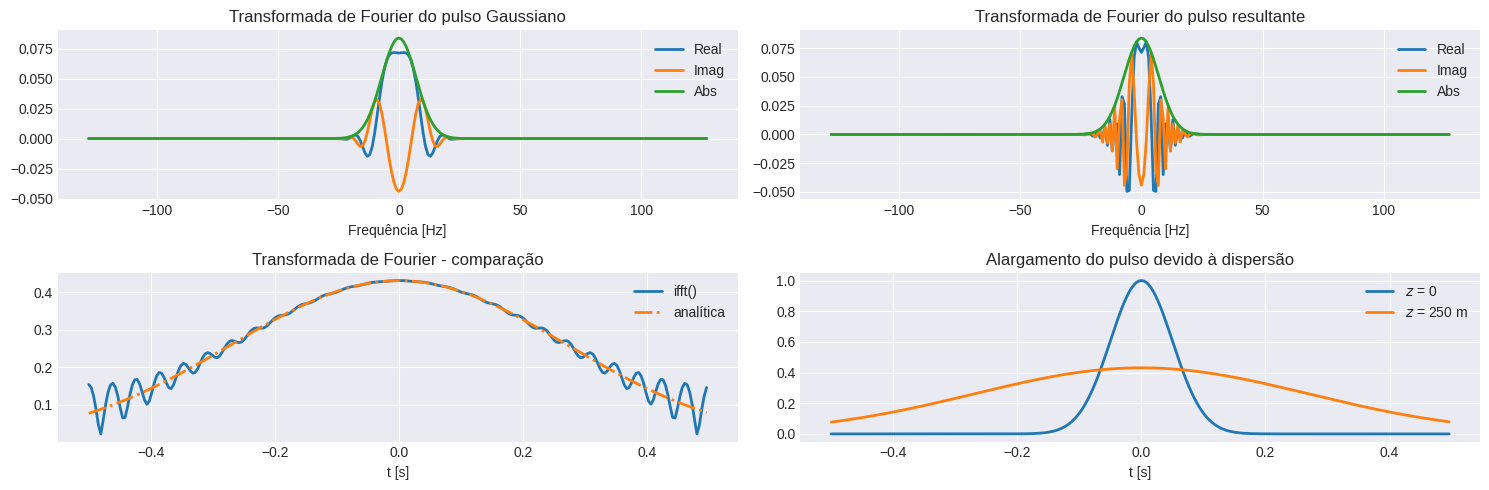

In [ ]:
fig, axs = plt.subplots(2,2, figsize=(15,5))
axs[0,0].plot(f, XC.real, label = "Real", linewidth = 2)
axs[0,0].plot(f, XC.imag, label = "Imag", linewidth = 2)
axs[0,0].plot(f, abs(XC), label = "Abs", linewidth = 2)
axs[0,0].set_xlabel("Frequência [Hz]")
axs[0,0].set_title("Transformada de Fourier do pulso Gaussiano")
axs[0,0].legend()

axs[0,1].plot(f, XHC.real, label = "Real", linewidth = 2)
axs[0,1].plot(f, XHC.imag, label = "Imag", linewidth = 2)
axs[0,1].plot(f, np.abs(XHC), label = "Abs", linewidth = 2)
axs[0,1].set_xlabel("Frequência [Hz]")
axs[0,1].set_title("Transformada de Fourier do pulso resultante")
axs[0,1].legend()

axs[1,0].plot(t, abs(xhC*L), label = "ifft()", linewidth = 2)
axs[1,0].plot(t, abs(xhAC), "-.", label = "analítica", linewidth = 2)
axs[1,0].set_xlabel("t [s]")
axs[1,0].set_title("Transformada de Fourier - comparação")
axs[1,0].legend()

axs[1,1].plot(t, abs(xC), label = r"$z$ = 0", linewidth = 2)
axs[1,1].plot(t, abs(xhAC), label = r"$z$ = %d m" %(z), linewidth = 2)
axs[1,1].set_xlabel("t [s]")
axs[1,1].set_title("Alargamento do pulso devido à dispersão")
axs[1,1].legend()

plt.tight_layout()

A partir do código apresentado, conseguimos simular um cenário mais próximo do comportamento real de pulsos ópticos propagando em fibras. Em sistemas reais, é comum a presença de chirp, causada por moduladores ou efeitos não lineares. Essa variação faz com que diferentes componentes espectrais se propaguem de maneira distinta, resultando em alargamento assimétrico do pulso. Portanto, incluir o efeito do chirp na simulação permite uma análise mais precisa da dispersão e das distorções do sinal ao longo da fibra óptica.

### Transmissão 10G OOK apenas com dispersão e perdas
---

O código abaixo simula uma transmissão óptica em um sistema de 10 Gbps (10G) utilizando modulação OOK (On-Off Keying) com a presença de dispersão cromática, prepara a base para análises mais complexas, como compensação de dispersão, uso de equalizadores ou modulações mais avançadas. A dispersão faz com que diferentes componentes espectrais de um pulso se propaguem a velocidades diferentes, causando alargamento do pulso e interferência entre símbolos. Onde o comprimento de dispersão é dado por:

$$
L_D = T_0^2/|β_2| \ ⟶ \ β_2 = -\frac{Dλ^2}{2πc}
$$

In [ ]:
# parâmetros da simulação
SpS = 32               # Amostra por simbolos
Rs     = 10e9          # Taxa de símbolos (para o caso do OOK Rs = Rb)
Ts     = 1/Rs          # Período de símbolo em segundos
Fa     = 1/(Ts/SpS)    # Frequência de amostragem do sinal (amostras/segundo)
Ta     = 1/Fa          # Período de amostragem
lmbd   = 1550e-9       # comprimento de onda
Pi_dBm = 0             # potência de sinal óptico na entrada do modulador em dBm

# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = (-paramMZM.Vpi/2)
Pi =  10**(Pi_dBm/10)*1e-3

# Parâmetros da fibra
D = 18e-6
beta2 = -(D*lmbd**2)/(2*np.pi*c)
z = 70e3
alphadB = 0.16
alpha   = 1e-3*alphadB/4.343
Rd  = 0.85

# gera sequência de bits pseudo-aleatórios e mapeia
bits   = np.random.randint(2, size=10000)
n      = np.arange(0, bits.size)
symb = 2*bits-1
symb = symb/np.sqrt(signal_power(symb))

# upsampling
symbolsUp = upsample(symb, SpS)
pulse = pulseShape("nrz", SpS)
pulse = pulse/max(abs(pulse))
t = np.arange(0, symb.size)*(Ta/1e-9)
idX = np.arange(0,1023)
sigft  = firFilter(pulse, symbolsUp)

Ai     = np.sqrt(Pi)
sigfto = mzm(Ai, -(paramMZM.Vb)*sigft, paramMZM)

# transmissão óptica
NFFT = len(sigfto)
sigftoFFT = np.fft.fftshift(np.fft.fft(sigfto))/NFFT
sigftoPt  = np.abs(sigftoFFT)**2
freq = np.fft.fftshift(np.fft.fftfreq(len(sigftoFFT), Ta))

# Fibra óptica
H  = np.exp(1j*0.5*beta2*z*(2*np.pi*freq)**2)
sigdpFFT = H * sigftoFFT
sigdpPt  = np.abs(sigdpFFT)**2
sigdp = np.fft.ifft(sigdpFFT)*NFFT

Potência do sinal (em dBm) = -3.01 dBm
Potência do sinal com dispersao (em dBm) = -3.01 dBm
Comprimento de dispersão [m]: 435576.729636
Comprimento efetivo de perdas [km]: 27.143750


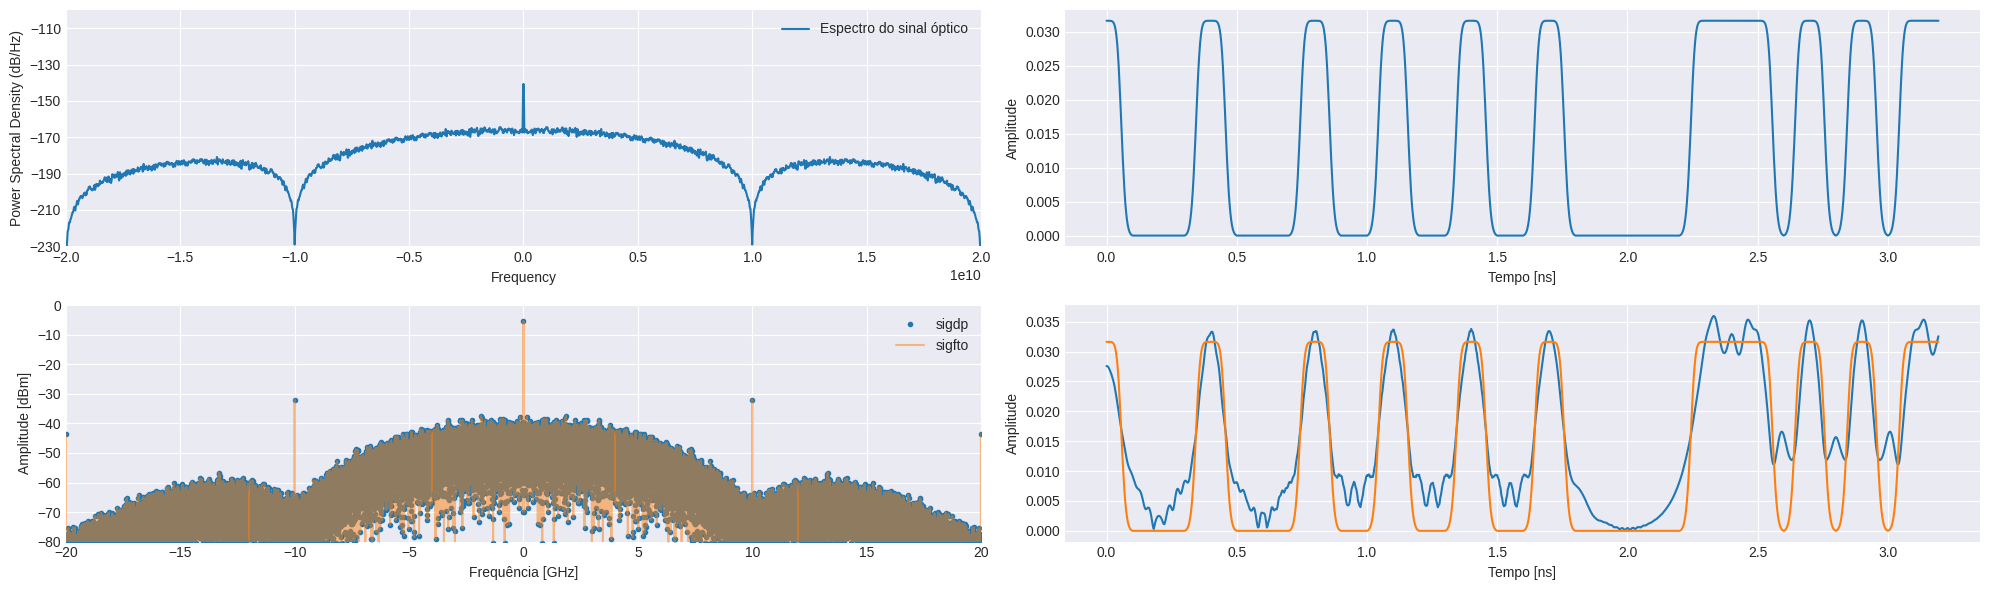

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(20,6))
axs[0,0].set_xlim(-2*Rs,2*Rs);
axs[0,0].set_ylim(-230,-100);
axs[0,0].psd(np.abs(sigfto)**2,Fs=Fa, NFFT = 16*1024, sides="twosided", label = "Espectro do sinal óptico")
axs[0,0].legend(loc="best")

axs[0,1].plot(t[idX], np.abs(sigfto[idX]))
axs[0,1].set_xlabel("Tempo [ns]")
axs[0,1].set_ylabel("Amplitude")

axs[1,0].plot(1e-9*freq, 10*np.log10(1e3*sigdpPt), ".", label = "sigdp")
axs[1,0].plot(1e-9*freq, 10*np.log10(1e3*sigftoPt), alpha = 0.5, label = "sigfto")
axs[1,0].set_ylabel("Amplitude [dBm]")
axs[1,0].set_xlabel("Frequência [GHz]")
axs[1,0].set_xlim(-2e-9*Rs,2e-9*Rs)
axs[1,0].set_ylim(-80,0)
axs[1,0].legend(loc = "best")

axs[1,1].plot(t[idX], abs(sigdp[idX]))
axs[1,1].plot(t[idX], abs(sigfto[idX]))
axs[1,1].set_xlabel("Tempo [ns]")
axs[1,1].set_ylabel("Amplitude")

print("Potência do sinal (em dBm) = %.2f dBm" %(10*np.log10(np.sum(sigftoPt)/1e-3)))
print("Potência do sinal com dispersao (em dBm) = %.2f dBm" %(10*np.log10(np.sum(sigdpPt)/1e-3)))
LD = (Ts**2)/abs(beta2)
print('Comprimento de dispersão [m]: %f' %(LD))
LP = 1e-3*1/alpha
print('Comprimento efetivo de perdas [km]: %f' %(LP))
plt.tight_layout()
plt.show()

Potência do sinal da fibra (em dBm) = -3.01 dBm
Potência do sinal com dispersao e perda (em dBm) = -14.21 dBm


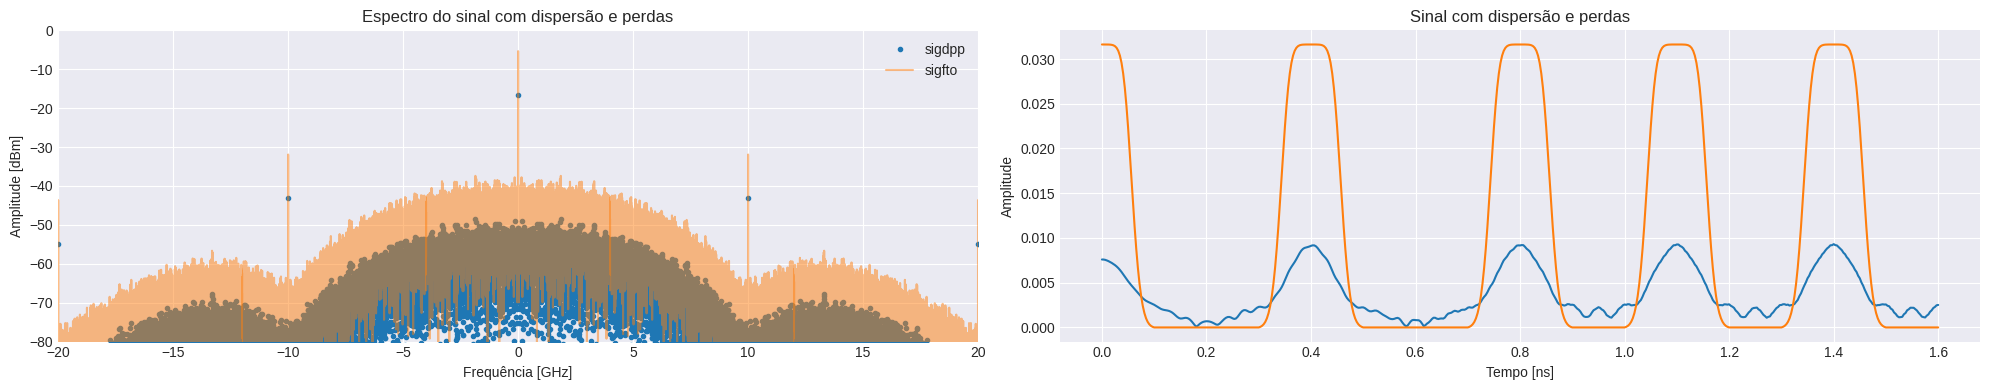

In [ ]:
# Fibra óptica com perdas
Hp  = np.exp(1j*0.5*beta2*z*(2*np.pi*freq)**2)*np.exp(-0.5*alpha*z) # Função de transferência do canal
sigdppFFT = Hp * sigftoFFT
sigdppPt  = np.abs(sigdppFFT)**2
sigdpp = np.fft.ifft(sigdppFFT)*NFFT

fig, axs = plt.subplots(1, 2, figsize=(20,4))
axs[0].plot(1e-9*freq, 10*np.log10(1e3*sigdppPt), ".", label = "sigdpp")
axs[0].plot(1e-9*freq, 10*np.log10(1e3*sigftoPt), alpha = 0.5, label = "sigfto")
axs[0].set_ylabel("Amplitude [dBm]")
axs[0].set_xlabel("Frequência [GHz]")
axs[0].set_title("Espectro do sinal com dispersão e perdas")
axs[0].set_xlim(-2e-9*Rs,2e-9*Rs)
axs[0].set_ylim(-80,0)
axs[0].legend(loc = "best")

axs[1].plot(t[0:513], abs(sigdpp[0:513]))
axs[1].plot(t[0:513], abs(sigfto[0:513]))
axs[1].set_title("Sinal com dispersão e perdas")
axs[1].set_xlabel("Tempo [ns]")
axs[1].set_ylabel("Amplitude")

print("Potência do sinal da fibra (em dBm) = %.2f dBm" %(10*np.log10(np.sum(sigftoPt)/1e-3)))
print("Potência do sinal com dispersao e perda (em dBm) = %.2f dBm" %(10*np.log10(np.sum(sigdppPt)/1e-3)))
plt.tight_layout()
plt.show()

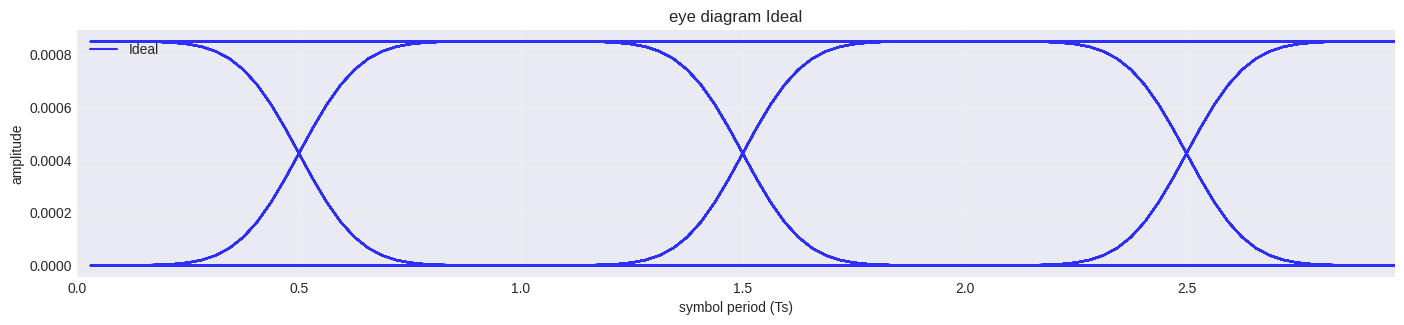

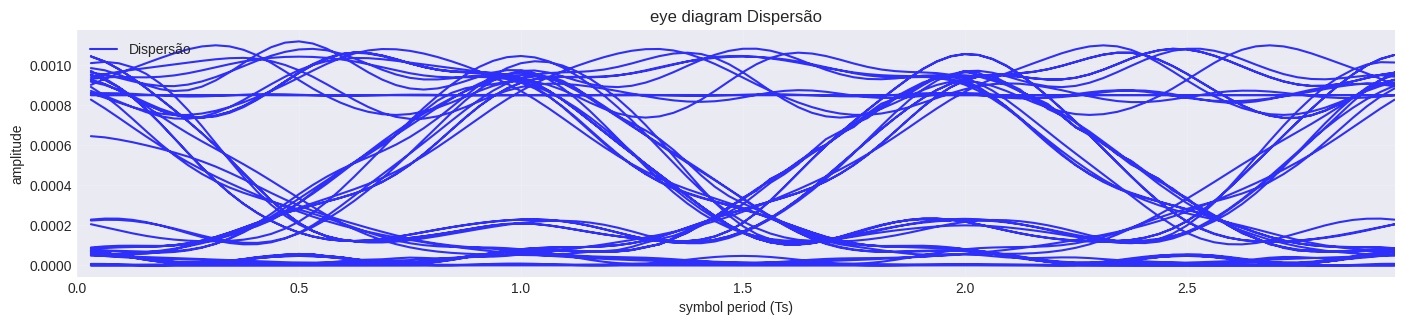

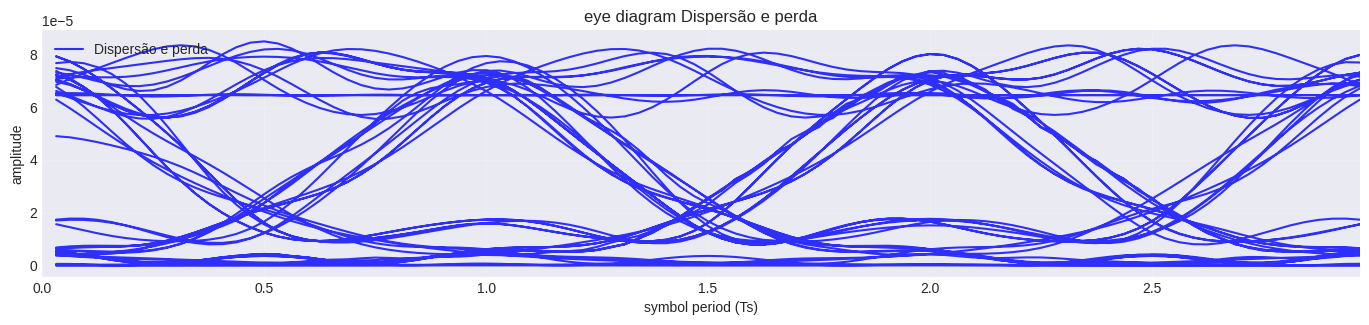

In [ ]:
# fotocorrente livre de ruído
Nsamples = 2**12
Ip   = Rd*np.abs(sigfto)**2
I_Rdp = Rd*np.abs(sigdp)**2
I_Rdpp = Rd*np.abs(sigdpp)**2

# diagrama de olho
eyediagram(Ip,  Nsamples, SpS,plotlabel='Ideal')
eyediagram(I_Rdp, Nsamples, SpS, plotlabel="Dispersão")
eyediagram(I_Rdpp, Nsamples, SpS, plotlabel="Dispersão e perda")